### Ejemplo: Un Árbol de Decisión para Aprobar un Préstamo
- Si los ingresos son mayores a $50,000, se considera el historial crediticio.
- Si el historial es bueno, el préstamo es aprobado.
- Si cualquiera de estos factores es negativo, el préstamo es rechazado.

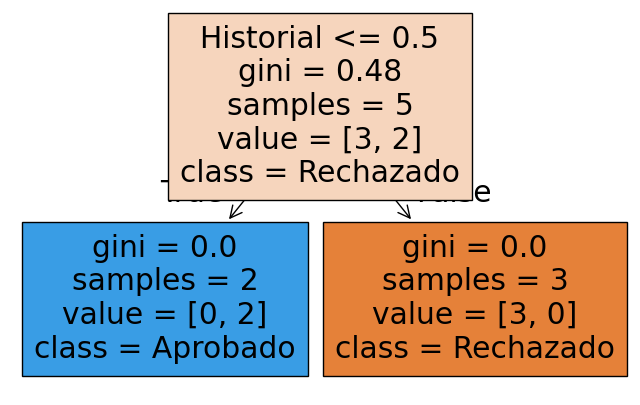

In [1]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Datos ficticios de ingresos y historial crediticio
X = [[60000, 1], [35000, 0], [80000, 1], [20000, 0], [50000, 1]]
y = ["Aprobado", "Rechazado", "Aprobado", "Rechazado", "Aprobado"]

# Crear y entrenar el árbol
tree = DecisionTreeClassifier(criterion="gini", max_depth=3)
tree.fit(X, y)

# Graficar el árbol
plt.figure(figsize=(8, 5))
plot_tree(tree, feature_names=["Ingreso", "Historial"], class_names=["Rechazado", "Aprobado"], filled=True)
plt.show()

### Ejemplo de Código en Python – Comparación de Clasificación vs. Regresión

In [2]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# Datos simulados
X_class = np.array([[1], [2], [3], [4], [5]])
y_class = np.array(["Bajo", "Bajo", "Medio", "Alto", "Alto"])

X_reg = np.array([[1], [2], [3], [4], [5]])
y_reg = np.array([10000, 15000, 25000, 50000, 70000])

# Modelos
clf = DecisionTreeClassifier(max_depth=2).fit(X_class, y_class)
reg = DecisionTreeRegressor(max_depth=2).fit(X_reg, y_reg)

# Predicción de nuevos valores
print("Clasificación:", clf.predict([[3.5]]))  # Esperado: "Medio" o "Alto"
print("Regresión:", reg.predict([[3.5]]))       # Esperado: Un valor numérico intermedio

Clasificación: ['Medio']
Regresión: [25000.]


### Ejemplo: Comparar ID3 y CART en Clasificación

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Cargar dataset Titanic
df = sns.load_dataset("titanic").dropna()

# Preprocesamiento
df["sex"] = df["sex"].map({"male": 1, "female": 0})
X = df[["age", "fare", "sex", "class"]]
y = df["survived"]

# Convertir "class" en variable numérica
X = pd.get_dummies(X, drop_first=True)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Árbol ID3 (simulado con entropy en scikit-learn)
tree_id3 = DecisionTreeClassifier(criterion="entropy", max_depth=3, random_state=42)
tree_id3.fit(X_train, y_train)
y_pred_id3 = tree_id3.predict(X_test)

# Árbol CART (scikit-learn usa Gini por defecto)
tree_cart = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
tree_cart.fit(X_train, y_train)
y_pred_cart = tree_cart.predict(X_test)

# Evaluación de precisión
print("Precisión ID3 (Entropía):", accuracy_score(y_test, y_pred_id3))
print("Precisión CART (Gini):", accuracy_score(y_test, y_pred_cart))


Precisión ID3 (Entropía): 0.7027027027027027
Precisión CART (Gini): 0.7027027027027027
